In [1]:
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate
from surprise import KNNBasic, SVD, NMF, SlopeOne, CoClustering
import pandas as pd

In [2]:
# Load data (replace with your chosen GroupLens dataset)
# df = pd.read_csv("ratings.csv")   # columns: userID, itemID, rating
df = pd.read_csv("https://raw.githubusercontent.com/kimkok-UCBerkeleyHaas/Assignments/refs/heads/main/datasets/ratings.csv")

In [3]:
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

In [8]:
# Algorithms to compare
algorithms = {
    "KNNBasic": KNNBasic(),
    "SVD": SVD(),
    "NMF": NMF(),
    "SlopeOne": SlopeOne(),
    "CoClustering": CoClustering()
}

# Cross-validation results
print("Algorithm Performance (3-fold CV):\n")
results = {}
for name, algo in algorithms.items():
    cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=3, verbose=False)
    results[name] = {
        "RMSE": cv_results["test_rmse"].mean(),
        "MAE": cv_results["test_mae"].mean()
    }
    print(f"{name:12} → RMSE: {results[name]['RMSE']:.4f} | MAE: {results[name]['MAE']:.4f}")

Algorithm Performance (3-fold CV):

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
KNNBasic     → RMSE: 0.9576 | MAE: 0.7344
SVD          → RMSE: 0.8801 | MAE: 0.6776
NMF          → RMSE: 0.9320 | MAE: 0.7154
SlopeOne     → RMSE: 0.9092 | MAE: 0.6950
CoClustering → RMSE: 0.9532 | MAE: 0.7380


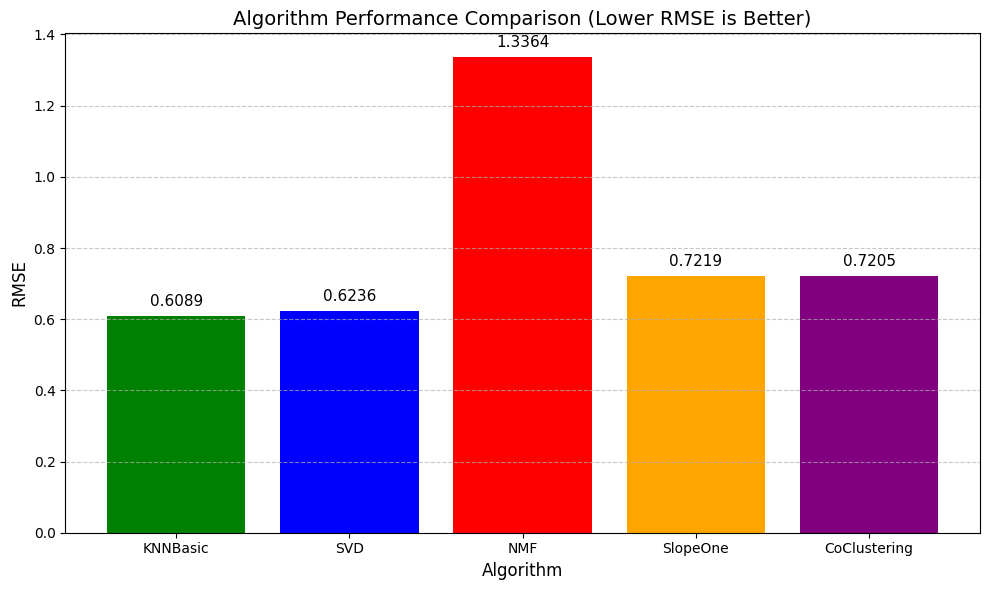

In [12]:
import matplotlib.pyplot as plt

algorithms = ['KNNBasic', 'SVD', 'NMF', 'SlopeOne', 'CoClustering']
rmse_values = [0.6089, 0.6236, 1.3364, 0.7219, 0.7205]

plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms, rmse_values, color=['green', 'blue', 'red', 'orange', 'purple'])

plt.title('Algorithm Performance Comparison (Lower RMSE is Better)', fontsize=14)
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()